# Medical Device Risk Class Prediction — Model Training (v3)
### Cognizant AI Hackathon — Team Notebook

**Input**: `outputs/train.csv`, `outputs/test.csv`, `outputs/preprocessor.pkl` (from the EDA/preprocessing notebook)

**Output**: `backend/app/ml/model.pkl`, `backend/app/ml/pipeline.pkl`, `outputs/metrics.json`

**Evaluation metric**: Macro-F1 (not accuracy — class imbalance: II≈76%, I≈17%, III≈7%)

**What's new in v3**: after selecting the best model via cross-validation (v2's fix for test-set
leakage during model selection), we diagnosed that the default argmax decision rule under-predicts
the minority classes (I and III) because the model hedges toward the majority class (II) on
borderline cases. We tune per-class decision weights on **out-of-fold predictions from the training
set only** (never touching test until final reporting) to correct this, then bake the tuned weights
into the saved model so the FastAPI backend gets correct behavior automatically — it just calls
`model.predict(X)`, it never needs to know weighting exists.


In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

sns.set_style('whitegrid')

OUT_DIR = Path('outputs')
BACKEND_ML_DIR = Path('../backend/app/ml')
BACKEND_ML_DIR.mkdir(parents=True, exist_ok=True)

# IMPORTANT: LabelOffsetClassifier / WeightedDecisionClassifier live in a shared module
# (not defined inline here) so the saved model.pkl can be unpickled by FastAPI in a
# separate process. Both sides must import from the exact same module path.
import sys
sys.path.insert(0, str(BACKEND_ML_DIR))
from model_classes import LabelOffsetClassifier, WeightedDecisionClassifier

FEATURE_COLS = [
    'classification', 'description',
    'mfr_total_events', 'mfr_distinct_countries',
    'mfr_distinct_devices_recalled', 'mfr_pct_class1_events',
    'description_len',
]
CLASS_LABELS = [1, 2, 3]
CLASS_NAMES = ['I', 'II', 'III']


## 1. Load data — defensively

In [2]:
preprocessor = joblib.load(OUT_DIR / 'preprocessor.pkl')

train_df = pd.read_csv(OUT_DIR / 'train.csv')
test_df = pd.read_csv(OUT_DIR / 'test.csv')

# CSV round-trips turn '' back into NaN by default -- re-clean rather than trust the file.
for df in (train_df, test_df):
    df['description'] = df['description'].fillna('')
    df['classification'] = df['classification'].fillna('Unknown')

assert train_df[FEATURE_COLS].isna().sum().sum() == 0, "Unexpected NaNs remain in train features"
assert test_df[FEATURE_COLS].isna().sum().sum() == 0, "Unexpected NaNs remain in test features"

X_train = train_df[FEATURE_COLS]
y_train = train_df['risk_class']
X_test = test_df[FEATURE_COLS]
y_test = test_df['risk_class']

X_train_t = preprocessor.transform(X_train)
X_test_t = preprocessor.transform(X_test)

print(f'Train: {X_train_t.shape}  |  Test: {X_test_t.shape}')
print(f'Classes: {sorted(y_train.unique())}')


Train: (26081, 522)  |  Test: (6521, 522)
Classes: [np.int64(1), np.int64(2), np.int64(3)]


## 2. XGBoost label wrapper (imported from `model_classes.py`)

XGBoost's sklearn API requires 0-indexed integer labels (`[0,1,2]`), but our classes are `[1,2,3]`
(FDA risk class I/II/III). `LabelOffsetClassifier`, imported above from the shared
`backend/app/ml/model_classes.py`, handles this and works correctly with
`cross_val_score`/`cross_val_predict`. It is **not defined inline here** -- a class defined inside
a notebook cell gets pickled with module path `__main__`, which does not exist in the FastAPI
process, so the saved model would fail to load outside this notebook.

## 3. Model selection via 5-fold stratified CV (training set only)

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidates = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=150, max_depth=18, min_samples_leaf=3,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': LabelOffsetClassifier(XGBClassifier(
        n_estimators=150, learning_rate=0.08, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss', random_state=42, n_jobs=-1
    )),
}

cv_results = {}
for name, model in candidates.items():
    scores = cross_val_score(model, X_train_t, y_train, cv=cv, scoring='f1_macro', n_jobs=1)
    cv_results[name] = scores
    print(f'{name:22s} CV Macro-F1 (argmax): {scores.mean():.4f}  (+/- {scores.std():.4f})')


Logistic Regression    CV Macro-F1 (argmax): 0.6726  (+/- 0.0041)


Random Forest          CV Macro-F1 (argmax): 0.7115  (+/- 0.0072)


XGBoost                CV Macro-F1 (argmax): 0.7620  (+/- 0.0059)


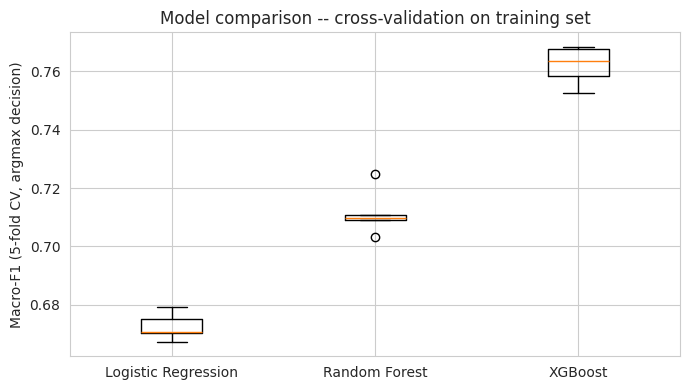

Selected model: XGBoost  (mean CV Macro-F1 = 0.7620)


In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(cv_results.values(), tick_labels=list(cv_results.keys()))
ax.set_ylabel('Macro-F1 (5-fold CV, argmax decision)')
ax.set_title('Model comparison -- cross-validation on training set')
plt.tight_layout()
plt.savefig(OUT_DIR / 'cv_comparison.png', dpi=110)
plt.show()

best_name = max(cv_results, key=lambda k: cv_results[k].mean())
print(f'Selected model: {best_name}  (mean CV Macro-F1 = {cv_results[best_name].mean():.4f})')


## 4. Diagnose the argmax decision rule

Before tuning anything, look at what the default (unweighted argmax) decision actually does on
out-of-fold predictions from the training set. This is the same diagnostic step as looking at a
confusion matrix -- just done without touching the test set.

In [5]:
oof_proba = cross_val_predict(
    candidates[best_name], X_train_t, y_train, cv=cv, method='predict_proba', n_jobs=1
)
classes_order = sorted(y_train.unique())  # [1, 2, 3] -- matches predict_proba column order

baseline_oof_pred = np.array(classes_order)[oof_proba.argmax(axis=1)]
baseline_oof_f1 = f1_score(y_train, baseline_oof_pred, average='macro')

print(f'{best_name} -- OOF macro-F1 with plain argmax: {baseline_oof_f1:.4f}')
print()
print(classification_report(y_train, baseline_oof_pred, target_names=CLASS_NAMES))
print('Confusion matrix (OOF, rows=actual, cols=predicted):')
print(confusion_matrix(y_train, baseline_oof_pred, labels=CLASS_LABELS))


XGBoost -- OOF macro-F1 with plain argmax: 0.7621

              precision    recall  f1-score   support

           I       0.90      0.43      0.58      4523
          II       0.86      0.99      0.92     19754
         III       0.96      0.67      0.78      1804

    accuracy                           0.87     26081
   macro avg       0.90      0.69      0.76     26081
weighted avg       0.87      0.87      0.85     26081

Confusion matrix (OOF, rows=actual, cols=predicted):
[[ 1950  2569     4]
 [  216 19488    50]
 [    6   598  1200]]


**What this shows**: recall on class I and III is noticeably lower than class II's, because on
borderline cases the model hedges toward class II -- it's the safe majority-class bet. Precision on
I/III stays high (when the model *does* call I or III, it's usually right), so this is specifically
a recall problem on the rare classes, not a broken model.

## 5. Tune per-class decision weights on out-of-fold predictions

Instead of `argmax(probabilities)`, use `argmax(probabilities * class_weights)`. Weights are
searched to maximize **OOF macro-F1 on the training set only** -- the test set is still untouched
at this point, so this tuning is not leakage.

In [6]:
weight_grid = [0.6, 0.8, 1.0, 1.2, 1.5, 1.8, 2.2, 2.6, 3.0]

best_oof_f1 = -1
best_weights = (1.0, 1.0, 1.0)
for w1 in weight_grid:
    for w3 in weight_grid:
        weights = np.array([w1, 1.0, w3])
        weighted_pred = np.array(classes_order)[(oof_proba * weights).argmax(axis=1)]
        f1 = f1_score(y_train, weighted_pred, average='macro')
        if f1 > best_oof_f1:
            best_oof_f1 = f1
            best_weights = (w1, 1.0, w3)

print(f'Best weights (I, II, III) = {best_weights}')
print(f'OOF macro-F1: {best_oof_f1:.4f}  (baseline argmax was {baseline_oof_f1:.4f}, '
      f'+{best_oof_f1 - baseline_oof_f1:.4f})')


Best weights (I, II, III) = (1.8, 1.0, 2.2)
OOF macro-F1: 0.8091  (baseline argmax was 0.7621, +0.0469)


## 6. Refit the winner on the full training set, wrap it with the tuned weights

`WeightedDecisionClassifier` (also imported from `model_classes.py`, for the same pickling reason
as above) bakes the weighting into `predict()` so downstream code (FastAPI) never needs to know
weighting exists -- it just calls `.predict(X)` and gets the corrected decision. `predict_proba()`
still returns the model's true, unweighted probabilities, since those are what you'd want to show
as a genuine confidence score in the UI.

In [7]:
base_model = clone(candidates[best_name])
base_model.fit(X_train_t, y_train)

final_model = WeightedDecisionClassifier(
    base_estimator=base_model,
    class_weights=list(best_weights),
    classes_order=classes_order,
)
final_model.fit(X_train_t, y_train)

print(f'Final model: {best_name} + decision weights {best_weights}')


Final model: XGBoost + decision weights (1.8, 1.0, 2.2)


## 7. Evaluate on test — the only time the test set is touched

In [8]:
y_pred_baseline = base_model.predict(X_test_t)
y_pred_weighted = final_model.predict(X_test_t)

test_f1_baseline = f1_score(y_test, y_pred_baseline, average='macro')
test_f1_weighted = f1_score(y_test, y_pred_weighted, average='macro')

print(f'TEST macro-F1 -- baseline (argmax):   {test_f1_baseline:.4f}')
print(f'TEST macro-F1 -- weighted (final):    {test_f1_weighted:.4f}')
print(f'Improvement:                          {test_f1_weighted - test_f1_baseline:+.4f}')
print()
print('=== Baseline (argmax) -- test classification report ===')
print(classification_report(y_test, y_pred_baseline, target_names=CLASS_NAMES))
print('=== Weighted (final model) -- test classification report ===')
print(classification_report(y_test, y_pred_weighted, target_names=CLASS_NAMES))


TEST macro-F1 -- baseline (argmax):   0.7443
TEST macro-F1 -- weighted (final):    0.7992
Improvement:                          +0.0549

=== Baseline (argmax) -- test classification report ===
              precision    recall  f1-score   support

           I       0.89      0.41      0.57      1131
          II       0.85      0.99      0.92      4939
         III       0.95      0.62      0.75       451

    accuracy                           0.86      6521
   macro avg       0.90      0.67      0.74      6521
weighted avg       0.87      0.86      0.84      6521

=== Weighted (final model) -- test classification report ===
              precision    recall  f1-score   support

           I       0.73      0.66      0.69      1131
          II       0.90      0.94      0.92      4939
         III       0.87      0.71      0.78       451

    accuracy                           0.87      6521
   macro avg       0.83      0.77      0.80      6521
weighted avg       0.87      0.87      

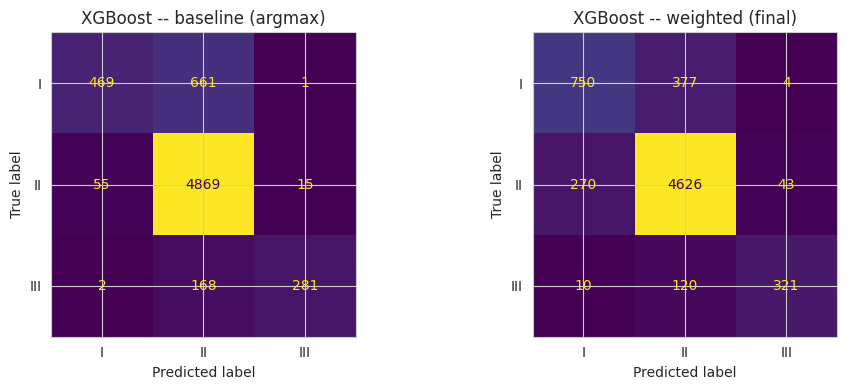

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm_baseline = confusion_matrix(y_test, y_pred_baseline, labels=CLASS_LABELS)
ConfusionMatrixDisplay(cm_baseline, display_labels=CLASS_NAMES).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'{best_name} -- baseline (argmax)')

cm_weighted = confusion_matrix(y_test, y_pred_weighted, labels=CLASS_LABELS)
ConfusionMatrixDisplay(cm_weighted, display_labels=CLASS_NAMES).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f'{best_name} -- weighted (final)')

plt.tight_layout()
plt.savefig(OUT_DIR / 'confusion_matrix_before_after.png', dpi=110)
plt.show()


## 8. Feature importance — quick explainability

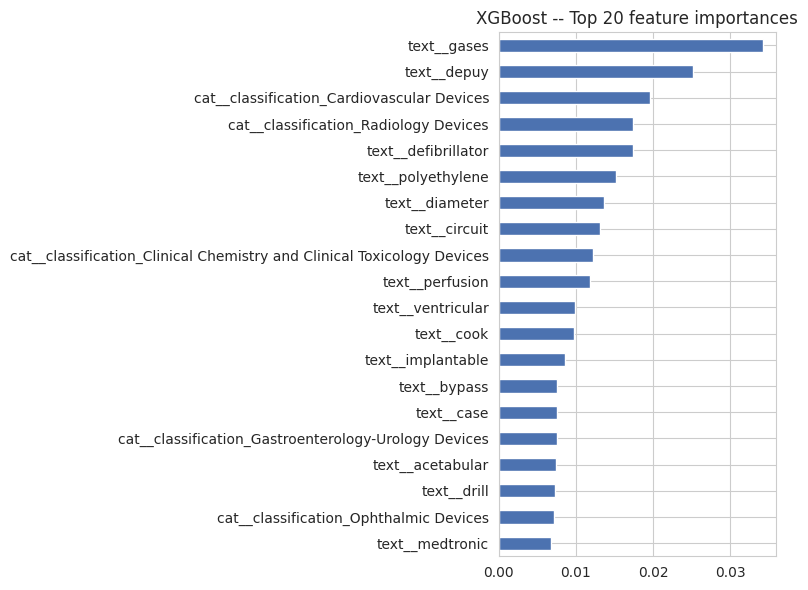

In [10]:
feature_names = preprocessor.get_feature_names_out()
underlying = base_model.base_estimator_ if hasattr(base_model, 'base_estimator_') else base_model

if hasattr(underlying, 'feature_importances_'):
    importances = pd.Series(underlying.feature_importances_, index=feature_names)
    top20 = importances.sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(8, 6))
    top20.sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
    ax.set_title(f'{best_name} -- Top 20 feature importances')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'feature_importance.png', dpi=110)
    plt.show()
else:
    print(f'{best_name} has no native feature_importances_ -- use coefficients or '
          f'permutation importance instead if this model is selected.')


## 9. Save artifacts

In [11]:
joblib.dump(preprocessor, OUT_DIR / 'pipeline.pkl')
joblib.dump(preprocessor, BACKEND_ML_DIR / 'pipeline.pkl')

joblib.dump(final_model, OUT_DIR / 'model.pkl')
joblib.dump(final_model, BACKEND_ML_DIR / 'model.pkl')

model_size_mb = (BACKEND_ML_DIR / 'model.pkl').stat().st_size / 1e6
print('pipeline.pkl and model.pkl saved to outputs/ and backend/app/ml/')
print(f'model.pkl size: {model_size_mb:.1f} MB')


pipeline.pkl and model.pkl saved to outputs/ and backend/app/ml/
model.pkl size: 1.1 MB


## 10. Save metrics + model version metadata

In [12]:
def per_class_report(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    return {
        str(cls): {
            'precision': round(report[str(cls)]['precision'], 4),
            'recall': round(report[str(cls)]['recall'], 4),
            'f1': round(report[str(cls)]['f1-score'], 4),
        }
        for cls in CLASS_LABELS
    }

metrics_payload = {
    'selected_model': best_name,
    'selection_method': '5-fold stratified CV on training set (macro-F1, argmax)',
    'decision_rule': 'argmax(predict_proba() * class_weights)',
    'class_weights': {'I': best_weights[0], 'II': best_weights[1], 'III': best_weights[2]},
    'cv_macro_f1_argmax': {
        name: {'mean': round(float(s.mean()), 4), 'std': round(float(s.std()), 4)}
        for name, s in cv_results.items()
    },
    'oof_macro_f1_baseline_argmax': round(float(baseline_oof_f1), 4),
    'oof_macro_f1_weighted': round(float(best_oof_f1), 4),
    'test_macro_f1_baseline_argmax': round(float(test_f1_baseline), 4),
    'test_macro_f1_weighted_final': round(float(test_f1_weighted), 4),
    'test_per_class_baseline': per_class_report(y_test, y_pred_baseline),
    'test_per_class_weighted': per_class_report(y_test, y_pred_weighted),
    'model_size_mb': round(model_size_mb, 1),
    'class_labels': CLASS_LABELS,
    'class_names': CLASS_NAMES,
}

with open(OUT_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics_payload, f, indent=2)

print(json.dumps(metrics_payload, indent=2))


{
  "selected_model": "XGBoost",
  "selection_method": "5-fold stratified CV on training set (macro-F1, argmax)",
  "decision_rule": "argmax(predict_proba() * class_weights)",
  "class_weights": {
    "I": 1.8,
    "II": 1.0,
    "III": 2.2
  },
  "cv_macro_f1_argmax": {
    "Logistic Regression": {
      "mean": 0.6726,
      "std": 0.0041
    },
    "Random Forest": {
      "mean": 0.7115,
      "std": 0.0072
    },
    "XGBoost": {
      "mean": 0.762,
      "std": 0.0059
    }
  },
  "oof_macro_f1_baseline_argmax": 0.7621,
  "oof_macro_f1_weighted": 0.8091,
  "test_macro_f1_baseline_argmax": 0.7443,
  "test_macro_f1_weighted_final": 0.7992,
  "test_per_class_baseline": {
    "1": {
      "precision": 0.8916,
      "recall": 0.4147,
      "f1": 0.5661
    },
    "2": {
      "precision": 0.8545,
      "recall": 0.9858,
      "f1": 0.9155
    },
    "3": {
      "precision": 0.9461,
      "recall": 0.6231,
      "f1": 0.7513
    }
  },
  "test_per_class_weighted": {
    "1": {
      

## 11. Sanity check -- load the saved model exactly as FastAPI would

This is the check that actually matters: a fresh, isolated load, not relying on anything already
in this notebook's memory. If this cell fails, the backend integration would fail too.

In [13]:
import subprocess

verify_script = f'''
import sys
sys.path.insert(0, {str(BACKEND_ML_DIR)!r})
import joblib
from model_classes import LabelOffsetClassifier, WeightedDecisionClassifier

pipeline = joblib.load({str(BACKEND_ML_DIR / "pipeline.pkl")!r})
model = joblib.load({str(BACKEND_ML_DIR / "model.pkl")!r})

import pandas as pd
sample = pd.DataFrame([{{
    "classification": "Cardiovascular",
    "description": "implantable cardiac defibrillator lead insulation failure",
    "mfr_total_events": 12,
    "mfr_distinct_countries": 3,
    "mfr_distinct_devices_recalled": 5,
    "mfr_pct_class1_events": 0.1,
    "description_len": 58,
}}])
X = pipeline.transform(sample)
pred = model.predict(X)
proba = model.predict_proba(X)
print("Loaded and predicted successfully.")
print("Predicted class:", pred[0])
print("Probabilities:", dict(zip(model.classes_, proba[0].round(3))))
'''

result = subprocess.run([sys.executable, '-c', verify_script], capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print("VERIFICATION FAILED:")
    print(result.stderr)
else:
    print("VERIFICATION PASSED -- model.pkl and pipeline.pkl are correctly loadable in a fresh process.")


Loaded and predicted successfully.
Predicted class: 3
Probabilities: {np.int64(1): np.float32(0.052), np.int64(2): np.float32(0.078), np.int64(3): np.float32(0.87)}

VERIFICATION PASSED -- model.pkl and pipeline.pkl are correctly loadable in a fresh process.


## Summary

| Artifact | Location | Used by |
|----------|----------|---------|
| `model.pkl` | `backend/app/ml/` | FastAPI `prediction_service.py` -- `.predict(X)` gives the weight-corrected class, `.predict_proba(X)` gives true confidence |
| `pipeline.pkl` | `backend/app/ml/` | FastAPI `prediction_service.py` -- transform raw input before prediction |
| `metrics.json` | `outputs/` | FastAPI `metrics_service.py` / `model_versions` table -- includes both baseline and weighted numbers for an honest "before/after" slide |
| `cv_comparison.png` | `outputs/` | Presentation -- model selection story |
| `confusion_matrix_before_after.png` | `outputs/` | Presentation -- the weighting fix, visually |
| `feature_importance.png` | `outputs/` | Presentation -- explainability |

**Inference flow** (matches `backend/app/services/prediction_service.py`):
```
raw input dict
  -> pipeline.pkl.transform()
  -> model.pkl.predict(X)          # already weight-corrected, returns 1/2/3
  -> model.pkl.predict_proba(X)    # true probabilities, for a confidence score
  -> { predicted_class, confidence, probabilities: {"I": .., "II": .., "III": ..} }
```

**Two caveats to say out loud in the presentation** (this is a good thing to volunteer, not hide):
1. `test_macro_f1_baseline_argmax` / `test_macro_f1_weighted_final` are single held-out measurements.
   The CV numbers (`cv_macro_f1_argmax`) are the more defensible generalization estimate.
2. The decision weights were tuned to maximize macro-F1 specifically -- if a judge asks "what if you
   care more about precision than recall on rare classes," that's a legitimate different choice of
   weights, and this pipeline makes that trivial to re-tune (just changes the search objective).
